In [1]:
import os
print("当前工作目录:", os.getcwd())

当前工作目录: c:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate


## 一.研究二维颗粒体系

- 这是复现Jamming最简单的2D 模型

### 1.绘制fast-slow压缩曲线

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1、文件路径
file_path_slow_rate = "compress_rate_0.0001/press_phi_compress_rate_0.0001.txt"
file_path_rate_fast_rate  = "compress_rate_0.001/press_phi_compress_rate_0.001.txt"


# 2、读取函数
def load_press_phi(file_path):
    df = pd.read_csv(file_path, sep=r"\s+")

    phi = df["phi"].values
    press = df["press"].values
    # 保证按 phi 从小到大排序
    sort_idx = np.argsort(phi)
    phi = phi[sort_idx]
    press = press[sort_idx]
    
    return phi, press


# 3、读取两组数据
phi_slow, press_slow = load_press_phi(file_path_slow_rate)
phi_fast, press_fast = load_press_phi(file_path_rate_fast_rate)

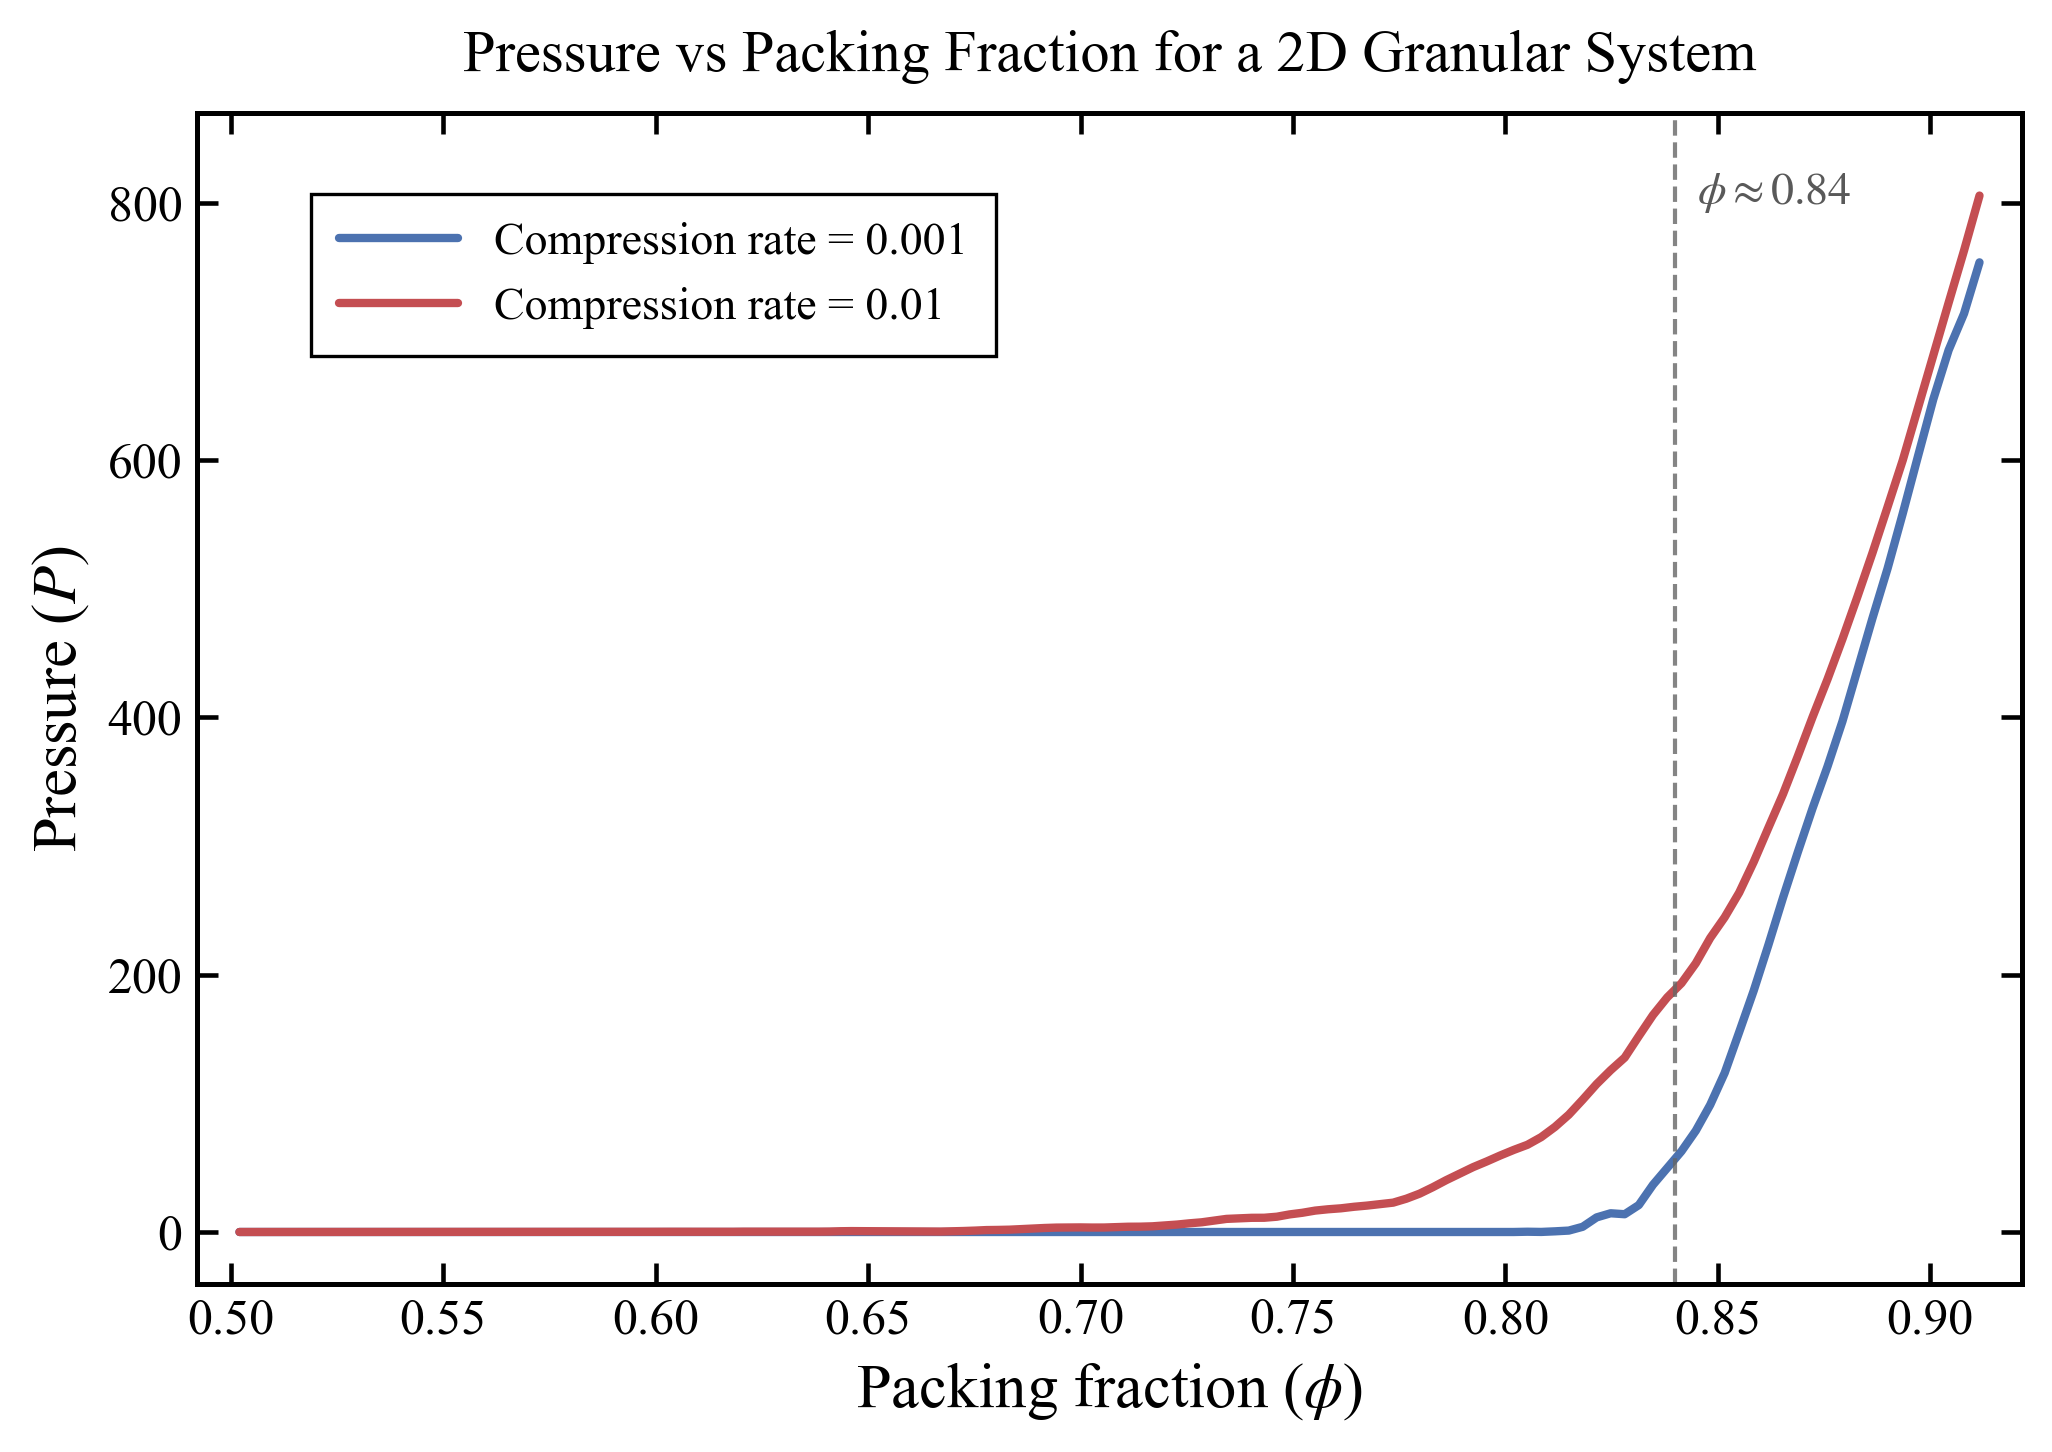

In [3]:
# ========= Nature-like style =========
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 15,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.linewidth": 1.2,
})

# ========= muted colors =========
color_slow = "#4C72B0"   # muted blue
color_fast = "#C44E52"   # muted red

# ========= figure =========
fig, ax = plt.subplots(figsize=(7.0, 5.0), dpi=300)

ax.plot(
    phi_slow, press_slow,
    lw=2.0, color=color_slow,
    label=r"Compression rate = 0.001",
    solid_capstyle="round"
)

ax.plot(
    phi_fast, press_fast,
    lw=2.0, color=color_fast,
    label=r"Compression rate = 0.01",
    solid_capstyle="round"
)

# ========= optional reference line =========
phi_j = 0.84
ax.axvline(phi_j, color="0.4", lw=1.0, ls="--", alpha=0.8)
ax.text(
    phi_j + 0.005, 0.95, r"$\phi \approx 0.84$",
    transform=ax.get_xaxis_transform(),
    ha="left", va="top", fontsize=11, color="0.35"
)

# ========= axes =========
xmin = min(np.min(phi_slow), np.min(phi_fast))
xmax = max(np.max(phi_slow), np.max(phi_fast))
ymin = min(np.min(press_slow), np.min(press_fast))
ymax = max(np.max(press_slow), np.max(press_fast))

ax.set_xlim(max(0.0, xmin - 0.01), min(1.0, xmax + 0.01))
ax.set_ylim(ymin - 0.05 * (ymax - ymin), ymax + 0.08 * (ymax - ymin))

ax.set_xlabel(r"Packing fraction ($\phi$)")
ax.set_ylabel(r"Pressure ($P$)")

# ========= ticks =========
ax.tick_params(axis="both", which="major", direction="in",
               top=True, right=True, length=5, width=1.1)
ax.tick_params(axis="both", which="minor", direction="in",
               top=True, right=True, length=3, width=0.9)

# ========= legend with paper-style frame =========
leg = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.05, 0.95),  # 👈 往里挪
    frameon=True,         # 打开边框
    fancybox=False,       # 直角框，更像论文
    framealpha=1.0,       # 不透明
    edgecolor="black",    # 黑色边框
    handlelength=2.6,
    borderpad=0.6
)
leg.get_frame().set_linewidth(0.8)   # 边框细一点，更像论文
leg.get_frame().set_facecolor("white")

# ========= spines =========
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("black")

ax.set_title("Pressure vs Packing Fraction for a 2D Granular System", pad=10)

plt.tight_layout()
plt.savefig("pictures/pressure_phi_curves.png", dpi=600, bbox_inches="tight")
plt.show()

### 2.绘制多种速率下的压缩曲线

#### 2.1 压缩速率在0.001-0.00001的对比曲线

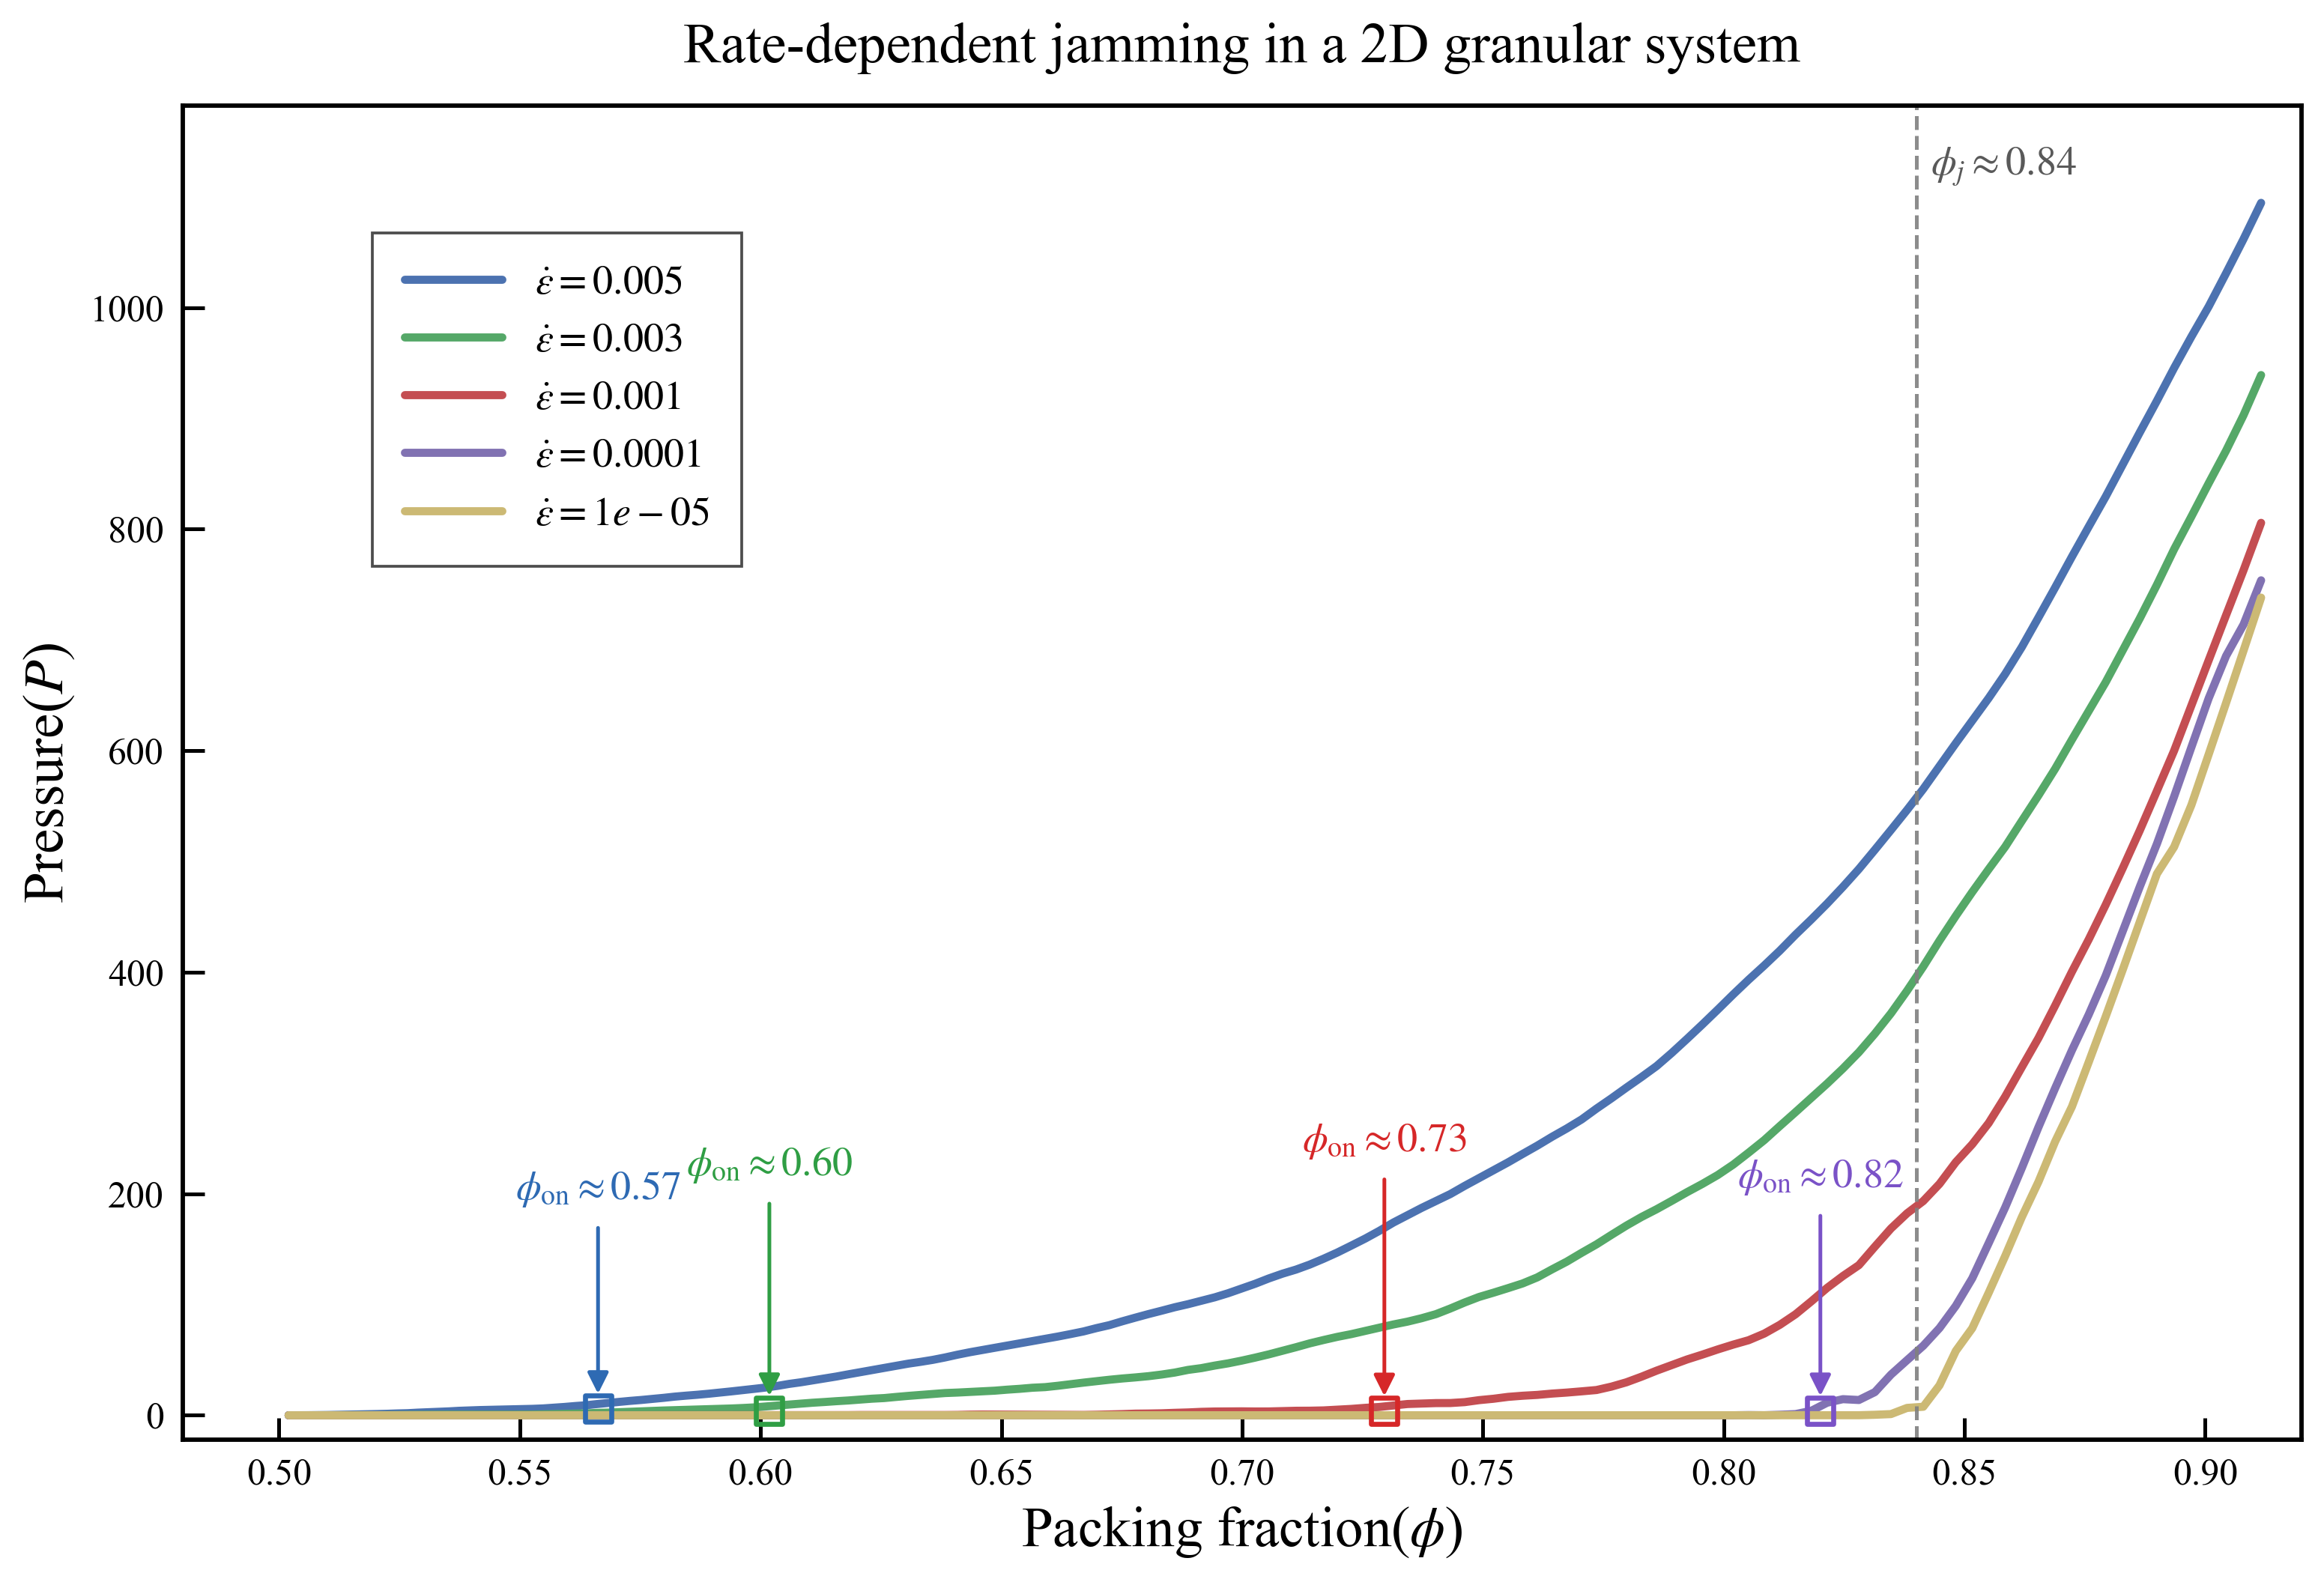

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# =========================
# 1. 文件路径
# =========================
file_dict = {
    5e-3: "compress_rate_0.005/press_phi_compress_rate_0.005.txt",
    3e-3: "compress_rate_0.003/press_phi_compress_rate_0.003.txt",
    1e-3: "compress_rate_0.001/press_phi_compress_rate_0.001.txt",
    1e-4: "compress_rate_0.0001/press_phi_compress_rate_0.0001.txt",
    1e-5: "compress_rate_0.00001/press_phi_compress_rate_0.00001.txt",
}

# =========================
# 2. 读取函数
# =========================
def load_press_phi(file_path):
    df = pd.read_csv(file_path, sep=r"\s+")
    phi = df["phi"].to_numpy()
    press = df["press"].to_numpy()

    # 按 phi 升序排序
    sort_idx = np.argsort(phi)
    phi = phi[sort_idx]
    press = press[sort_idx]
    return phi, press

# =========================
# 3. 读取所有数据
# =========================
data_dict = {}
for rate, path in file_dict.items():
    phi, press = load_press_phi(path)
    data_dict[rate] = (phi, press)

# =========================
# 4. 自动寻找“开始分叉点”
#    这里采用：相邻两条曲线开始明显偏离的位置
# =========================
def find_branch_point(phi1, p1, phi2, p2, phi_min=None, phi_max=None,
                      abs_threshold=8.0, rel_threshold=0.12, n_grid=1500):
    """
    找两条曲线开始明显偏离的位置
    条件：
        abs(p1-p2) > abs_threshold
    且
        abs(p1-p2)/max(max(|p1|,|p2|),1) > rel_threshold
    返回:
        phi_branch, p_mid
    """
    x_min = max(np.min(phi1), np.min(phi2))
    x_max = min(np.max(phi1), np.max(phi2))

    if phi_min is not None:
        x_min = max(x_min, phi_min)
    if phi_max is not None:
        x_max = min(x_max, phi_max)

    phi_common = np.linspace(x_min, x_max, n_grid)

    f1 = interp1d(phi1, p1, kind="linear", bounds_error=False, fill_value="extrapolate")
    f2 = interp1d(phi2, p2, kind="linear", bounds_error=False, fill_value="extrapolate")

    p1i = f1(phi_common)
    p2i = f2(phi_common)

    abs_diff = np.abs(p1i - p2i)
    scale = np.maximum(np.maximum(np.abs(p1i), np.abs(p2i)), 1.0)
    rel_diff = abs_diff / scale

    mask = (abs_diff > abs_threshold) & (rel_diff > rel_threshold)

    if np.any(mask):
        idx = np.argmax(mask)
        phi_b = phi_common[idx]
        p_b = 0.5 * (p1i[idx] + p2i[idx])
        return phi_b, p_b
    else:
        return None, None

# =========================
# 5. 设定风格
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.linewidth": 1.4,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# =========================
# 6. 颜色（按图片1风格）
# =========================
curve_colors = {
    5e-3: "#4C72B0",   # blue
    3e-3: "#55A868",   # green
    1e-3: "#C44E52",   # red
    1e-4: "#8172B2",   # purple
    1e-5: "#CCB974",   # golden
}

# 标注颜色（和曲线一致）
anno_colors = {
    5e-3: "#2E6AB3",
    3e-3: "#2F9E44",
    1e-3: "#D62728",
    1e-4: "#7A52C7",
}

# =========================
# 7. 排序（从大速率到小速率）
# =========================
rates_sorted = sorted(data_dict.keys(), reverse=True)

# =========================
# 8. 作图
# =========================
fig, ax = plt.subplots(figsize=(10.5, 7.2), dpi=300)

for rate in rates_sorted:
    phi, press = data_dict[rate]
    ax.plot(
        phi, press,
        lw=2.6,
        color=curve_colors[rate],
        solid_capstyle="round",
        label=rf"$\dot{{\epsilon}} = {rate:g}$"
    )

# =========================
# 9. 自动找4个“开始分叉点”
#    这里比较的是相邻两条曲线：
#    (5e-3 vs 3e-3), (3e-3 vs 1e-3), (1e-3 vs 1e-4), (1e-4 vs 1e-5)
# =========================
pair_list = [
    (5e-3, 3e-3),
    (3e-3, 1e-3),
    (1e-3, 1e-4),
    (1e-4, 1e-5),
]

branch_points = []

for r1, r2 in pair_list:
    phi1, p1 = data_dict[r1]
    phi2, p2 = data_dict[r2]

    phi_b, p_b = find_branch_point(
        phi1, p1, phi2, p2,
        phi_min=0.50, phi_max=0.90,
        abs_threshold=8.0,
        rel_threshold=0.12,
        n_grid=1500
    )

    if phi_b is not None:
        branch_points.append((r1, r2, phi_b, p_b))

# =========================
# 10. 参考竖线 phi_j
# =========================
phi_j = 0.84
ax.axvline(phi_j, color="0.5", lw=1.2, ls="--", alpha=0.9)
ax.text(
    phi_j + 0.003, 0.97, r"$\phi_j \approx 0.84$",
    transform=ax.get_xaxis_transform(),
    ha="left", va="top", fontsize=13, color="0.35"
)

# =========================
# 11. 标出分叉点（图片1风格）
# =========================
# 为了让箭头和文字排布更像你给的图，手动设一点偏移
text_y_factor = [0.17, 0.19, 0.21, 0.18]

ymax_all = max(np.max(data_dict[r][1]) for r in data_dict)
ymin_all = min(np.min(data_dict[r][1]) for r in data_dict)
yrange = ymax_all - ymin_all

for i, (r1, r2, phi_b, p_b) in enumerate(branch_points):
    c = anno_colors[r1]

    # 空心方框
    ax.scatter(
        phi_b, p_b,
        s=70,
        marker="s",
        facecolors="none",
        edgecolors=c,
        linewidths=1.6,
        zorder=6
    )

    # 箭头文字
    y_text = ymin_all + text_y_factor[i] * yrange

    ax.annotate(
        rf"$\phi_{{\mathrm{{on}}}} \approx {phi_b:.2f}$",
        xy=(phi_b, p_b + 2),
        xytext=(phi_b, y_text),
        textcoords="data",
        ha="center",
        va="bottom",
        fontsize=13,
        color=c,
        arrowprops=dict(
            arrowstyle="-|>",
            color=c,
            lw=1.2,
            shrinkA=4,
            shrinkB=4,
            mutation_scale=14
        )
    )

# =========================
# 12. 坐标范围
# =========================
all_phi = np.concatenate([data_dict[r][0] for r in data_dict])
all_press = np.concatenate([data_dict[r][1] for r in data_dict])

x_margin = 0.008
y_margin_lower = 0.02 * (np.max(all_press) - np.min(all_press))
y_margin_upper = 0.08 * (np.max(all_press) - np.min(all_press))

ax.set_xlim(0.48, 0.92)
ax.set_ylim(np.min(all_press) - y_margin_lower, np.max(all_press) + y_margin_upper)

# =========================
# 13. 标签
# =========================
ax.set_xlabel(r"Packing fraction($\phi$)")
ax.set_ylabel(r"Pressure($P$)")

# ==================================
# 14. 刻度：上边、右边不要刻度线
# ==================================
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=False,      # 关键：上边不要刻度
    right=False,    # 关键：右边不要刻度
    length=7,
    width=1.2,
    pad=6
)
ax.minorticks_off()

# =========================
# 15. 图例
# =========================
leg = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.08, 0.92),   # 👈 往右+往下挪
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor="0.3",
    fontsize=13, 
    handlelength=2.4,
    borderpad=0.8,
    labelspacing=0.5
)
leg.get_frame().set_linewidth(0.9)
leg.get_frame().set_facecolor("white")

# =========================
# 16. 边框
# =========================
ax.spines["top"].set_linewidth(1.4)
ax.spines["right"].set_linewidth(1.4)
ax.spines["left"].set_linewidth(1.4)
ax.spines["bottom"].set_linewidth(1.4)

# =========================
# 17. 标题
# =========================
ax.set_title("Rate-dependent jamming in a 2D granular system", pad=14)

plt.tight_layout()
plt.savefig("pictures/pressure_phi_all_rates.png", dpi=600, bbox_inches="tight")
plt.show()


- 补充多个速率下的实验点

In [5]:
import numpy as np
import pandas as pd
import os
# ========= 1、所有压缩速率文件 =========
file_dict = {
    1e-2: "compress_rate_0.01/press_phi_compress_rate_0.01.txt",
    7e-3: "compress_rate_0.007/press_phi_compress_rate_0.007.txt",
    5e-3: "compress_rate_0.005/press_phi_compress_rate_0.005.txt",
    3e-3: "compress_rate_0.003/press_phi_compress_rate_0.003.txt",
    1e-3: "compress_rate_0.001/press_phi_compress_rate_0.001.txt",
    1e-4: "compress_rate_0.0001/press_phi_compress_rate_0.0001.txt",
    1e-5: "compress_rate_0.00001/press_phi_compress_rate_0.00001.txt",
}



# =========================================================
# 参数（可以微调）
# =========================================================
DERIV_THRESHOLD = 300      # dP/dphi 阈值（关键参数）
SMOOTH_WINDOW = 5         # 平滑窗口（奇数）

# =========================================================
# 平滑函数（简单移动平均）
# =========================================================
def smooth(y, window=5):
    if window < 3:
        return y
    return np.convolve(y, np.ones(window)/window, mode="same")

# =========================================================
# 读取函数（和你保持一致）
# =========================================================
def load_press_phi(file_path):
    df = pd.read_csv(file_path, sep=r"\s+")

    phi = df["phi"].to_numpy()
    press = df["press"].to_numpy()

    idx = np.argsort(phi)
    return phi[idx], press[idx]

# =========================================================
# 自动提取 φ_on
# =========================================================
def detect_phi_on(phi, press):
    # 平滑压力
    press_s = smooth(press, SMOOTH_WINDOW)

    # 数值导数
    dP = np.gradient(press_s, phi)

    # 找到第一个超过阈值的位置
    idx_candidates = np.where(dP > DERIV_THRESHOLD)[0]

    if len(idx_candidates) == 0:
        return np.nan  # 没找到
    else:
        return phi[idx_candidates[0]]

# =========================================================
# 主循环
# =========================================================
results = []

for rate, path in file_dict.items():
    if not os.path.exists(path):
        print(f"[WARN] 文件不存在: {path}")
        continue

    phi, press = load_press_phi(path)

    phi_on = detect_phi_on(phi, press)

    results.append({
        "rate": rate,
        "phi_on": phi_on
    })

# =========================================================
# 保存为 CSV
# =========================================================
df_out = pd.DataFrame(results)

# 按 rate 从大到小排序（更直观）
df_out = df_out.sort_values(by="rate", ascending=False)

save_path = "phi_compressed_rate.csv"
df_out.to_csv(save_path, index=False)

print("✔ 已保存:", save_path)
print(df_out)

✔ 已保存: phi_compressed_rate.csv
      rate    phi_on
0  0.01000  0.502006
1  0.00700  0.526715
2  0.00500  0.559319
3  0.00300  0.601119
4  0.00100  0.725587
5  0.00010  0.811669
6  0.00001  0.831405


A = 5.059716, alpha = 0.554495


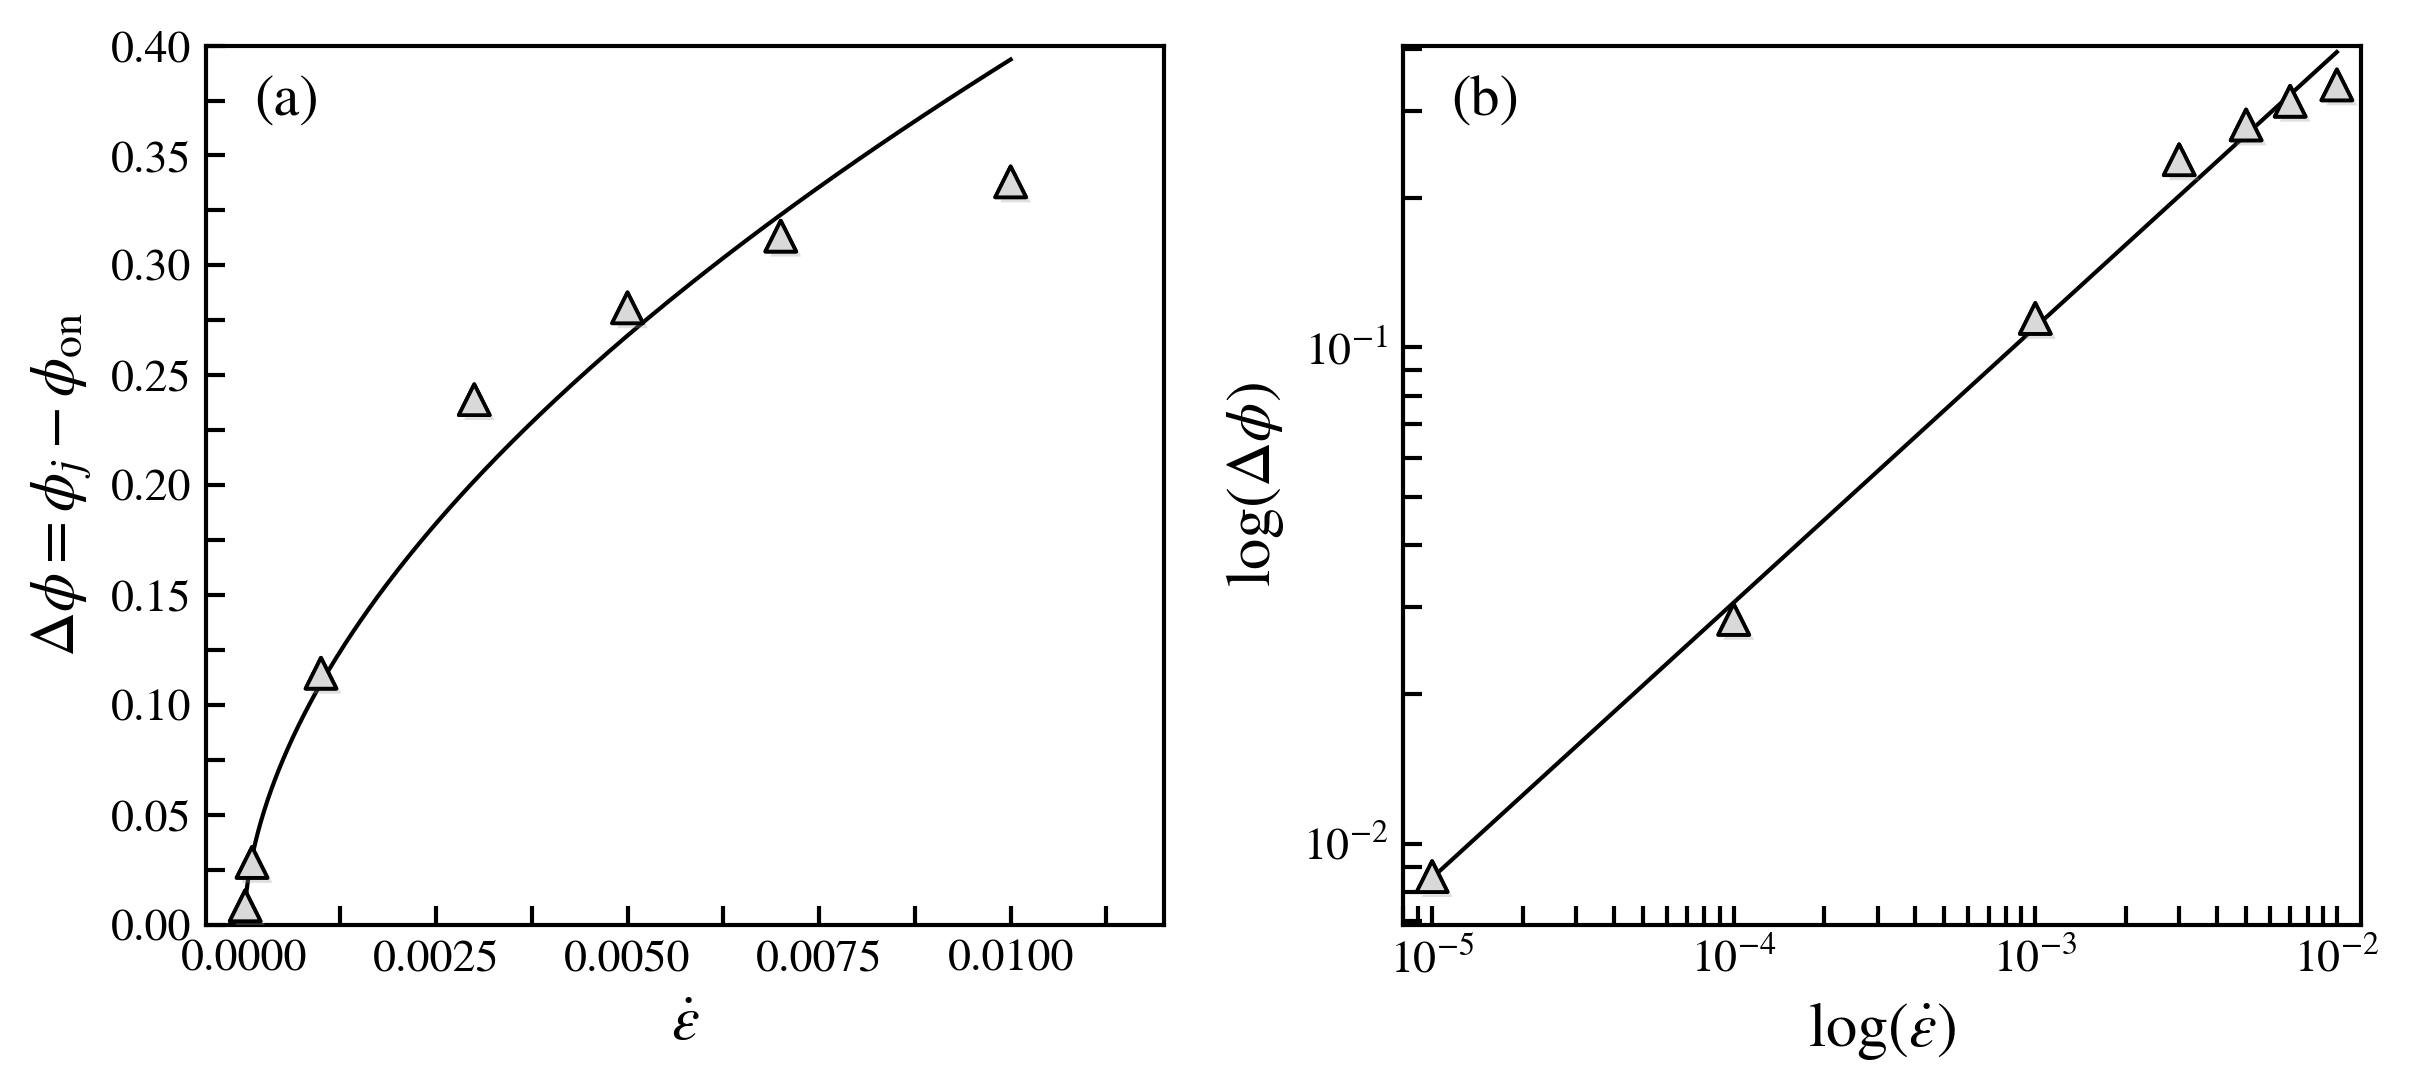

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter
import matplotlib.patheffects as pe

# =========================================================
# 1. 读取数据
# =========================================================
csv_path = "phi_compressed_rate.csv"
phi_j = 0.84

df = pd.read_csv(csv_path)
df = df.sort_values("rate").reset_index(drop=True)

rate = df["rate"].to_numpy()
phi_on = df["phi_on"].to_numpy()
delta_phi = phi_j - phi_on

mask = delta_phi > 0
rate = rate[mask]
delta_phi = delta_phi[mask]

# =========================================================
# 2. 拟合
# =========================================================
logx = np.log10(rate)
logy = np.log10(delta_phi)

coef = np.polyfit(logx, logy, deg=1)
alpha = coef[0]
A = 10 ** coef[1]

rate_fit = np.logspace(np.log10(rate.min()), np.log10(rate.max()), 400)
delta_phi_fit = A * rate_fit ** alpha

print(f"A = {A:.6f}, alpha = {alpha:.6f}")

# =========================================================
# 3. 风格
# =========================================================
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# =========================================================
# 4. 画布
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8), dpi=300)

# =========================================================
# 公共设置
# =========================================================
for ax in axes:
    ax.set_facecolor("white")

    # ❗关键：去掉上/右刻度
    ax.tick_params(
        which="both",
        direction="in",
        top=False,
        right=False,
        length=4.5,
        width=1.0
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

# =========================================================
# marker 风格（带阴影三角形）
# =========================================================
def scatter_with_shadow(ax, x, y):
    sc = ax.scatter(
        x, y,
        marker="^",
        s=55,
        facecolor="#d9d9d9",
        edgecolor="black",
        linewidth=0.9,
        zorder=3
    )
    # 阴影效果（关键）
    sc.set_path_effects([
        pe.withSimplePatchShadow(offset=(1.2, -1.2), shadow_rgbFace="0.6"),
        pe.Normal()
    ])

# =========================================================
# (a) 线性图
# =========================================================
ax = axes[0]

ax.plot(rate_fit, delta_phi_fit, color="black", lw=1.0)
scatter_with_shadow(ax, rate, delta_phi)

ax.set_xlabel(r"$\dot{\epsilon}$")
ax.set_ylabel(r"$\Delta \phi = \phi_j - \phi_{\mathrm{on}}$")
ax.text(0.05, 0.92, "(a)", transform=ax.transAxes, fontsize=14)

# ax.set_xlim(rate.min()*0.9, rate.max()*1.05)
# ax.set_ylim(delta_phi.min()*0.8, delta_phi.max()*1.1)
ax.set_xlim(-0.0005, 0.012)
ax.set_ylim(0, 0.40)


ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# =========================================================
# (b) 双对数图
# =========================================================
ax = axes[1]

ax.plot(rate_fit, delta_phi_fit, color="black", lw=1.0)
scatter_with_shadow(ax, rate, delta_phi)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"log($\dot{\epsilon}$)")
ax.set_ylabel(r"log($\Delta \phi$)")
ax.text(0.05, 0.92, "(b)", transform=ax.transAxes, fontsize=14)

ax.set_xlim(rate.min()*0.8, rate.max()*1.2)
ax.set_ylim(delta_phi.min()*0.8, delta_phi.max()*1.2)

# log minor ticks（只在下和左）
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

# =========================================================
# 保存
# =========================================================
plt.tight_layout(w_pad=1.2)
plt.savefig("pictures/jammingPoint_phi.png", dpi=600, bbox_inches="tight")
plt.show()

### 2.绘制RDF曲线

In [7]:
# 注意当前工作目录是  Jamming/compress_rate
import sys
sys.path.append("..")   # 返回到上级目录 /Jamming 根目录


from utils.compute_rdf import compute_rdf_fn
from utils.draw_rdf import draw_rdf_fn

In [8]:
# 计算compress_rate=0.001下的RDF曲线
INPUT_FILE = "compress_rate_0.001/traj_compress_rate_0.001.xyz"
OUTPUT_DIR = "compress_rate_0.001/rdf_output"

compute_rdf_fn(INPUT_FILE=INPUT_FILE, OUTPUT_DIR=OUTPUT_DIR, START_FRAME=1)

[INFO] Input trajectory : compress_rate_0.001\traj_compress_rate_0.001.xyz
[INFO] Output directory : C:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate\compress_rate_0.001\rdf_output
[INFO] R_MAX = 10.0, DR = 0.02
[INFO] Saved frame 1, timestep = 0
[INFO] Saved frame 2, timestep = 5000
[INFO] Saved frame 3, timestep = 10000
[INFO] Saved frame 4, timestep = 15000
[INFO] Saved frame 5, timestep = 20000
[INFO] Saved frame 6, timestep = 25000
[INFO] Saved frame 7, timestep = 30000
[INFO] Saved frame 8, timestep = 35000
[INFO] Saved frame 9, timestep = 40000
[INFO] Saved frame 10, timestep = 45000
[INFO] Saved frame 11, timestep = 50000
[INFO] Saved frame 12, timestep = 55000
[INFO] Saved frame 13, timestep = 60000
[INFO] Saved frame 14, timestep = 65000
[INFO] Saved frame 15, timestep = 70000
[INFO] Saved frame 16, timestep = 75000
[INFO] Saved frame 17, timestep = 80000
[INFO] Saved frame 18, timestep = 85000
[INFO] Saved frame 19, timestep = 90000
[INFO] Saved frame 

[DONE] Figure saved to: compress_rate_0.001/rdf_compare.png


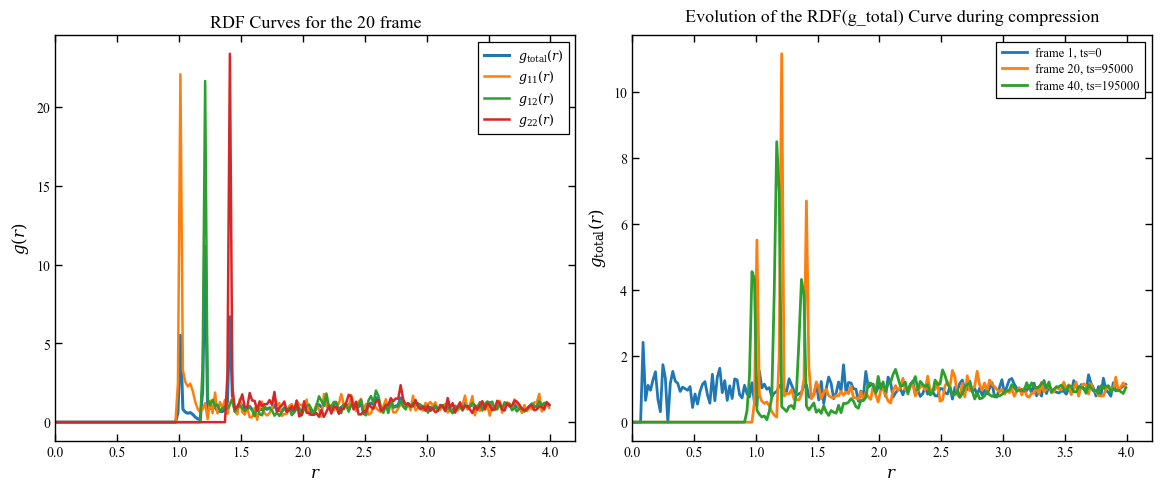

In [9]:
rdf_dir = "compress_rate_0.001/rdf_output"
save_fig_path = "compress_rate_0.001/rdf_compare.png"

single_frame = 20
compare_frames = [1, 20, 40]
compare_column = "g_total"   # 可选: g_total, g11, g12, g22


# 这是utils写好的函数, 直接按要求调用即可
draw_rdf_fn(RDF_DIR = rdf_dir, 
            SAVE_FIG_PATH = save_fig_path,
            SINGLE_FRAME = single_frame, 
            COMPARE_FRAMES = compare_frames,
            COMPARE_COLUMN = compare_column)

### 3.绘制tau-phi曲线

In [10]:
# 注意当前工作目录是  Jamming/compress_rate
import sys
sys.path.append("..")   # 返回到上级目录 /Jamming 根目录

from utils.compute_tau import compute_tau_fn, draw_tau_fn

=============== Parameter Info ===================
[INFO] D             : 1.0
[INFO] R_MAX         : 10.0
[INFO] SCALE         : 0.998
[DONE] Saved all-frame tau data to: C:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate\compress_rate_0.001\all_frames_tau.csv
[DONE] Figure saved to: C:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate\compress_rate_0.001\pictures\tau_phi_curve.png


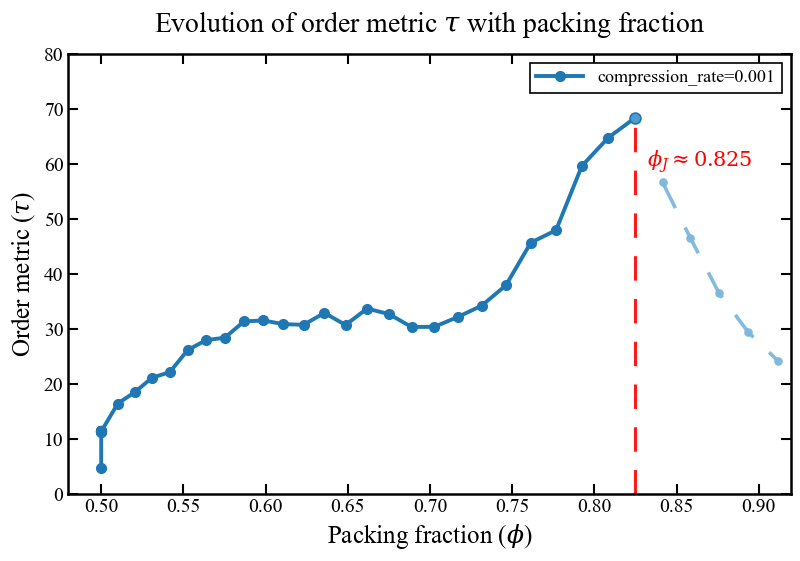

In [11]:
rdf_dir = "compress_rate_0.001/rdf_output"
output_csv = "compress_rate_0.001/all_frames_tau.csv"
g_column = "g_total"     # 可选: g_total, g11, g12, g22
save_fig_path = "compress_rate_0.001/pictures/tau_phi_curve.png"


# 1.从单个压缩实验中读取rdf_dir目录下的所有文件,然后计算出一个tau-phi值
compute_tau_fn(RDF_DIR=rdf_dir, OUTPUT_CSV=output_csv, G_COLUMN=g_column)

# 2.绘制对应的tau-phi曲线图
draw_tau_fn(INPUT_CSV=output_csv, SAVE_FIG=save_fig_path)

 - 值得注意的是: 在本次实验中, phi_j=0.825(而不是0.844),原因有两方面:
    - 涨落影响: 只是计算了单个实验中的体系变化, 而0.844是统计下的理论值
    - 有限压缩速率: 本实验压缩速率为0.001, 达不到FIRE能量最小化的效果

### 4.绘制Z distribution柱状图

In [12]:
# 注意当前工作目录是  Jamming/compress_rate
import sys
sys.path.append("..")   # 返回到上级目录 /Jamming 根目录

from utils.compute_z import compute_z_distribution_fn, draw_z_distribution_fn

[INFO] Input trajectory : compress_rate_0.001\traj_compress_rate_0.001.xyz
[INFO] Output directory : C:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate\compress_rate_0.001\z_output
[INFO] CONTACT_TOL = 0.001
[DONE] Total processed frames: 41
[DONE] Figure saved to: C:\Users\13557\Desktop\LammpsProject\shentongtong\Jamming\compress_rate\compress_rate_0.001\pictures\z_distribution_multi_frames.png


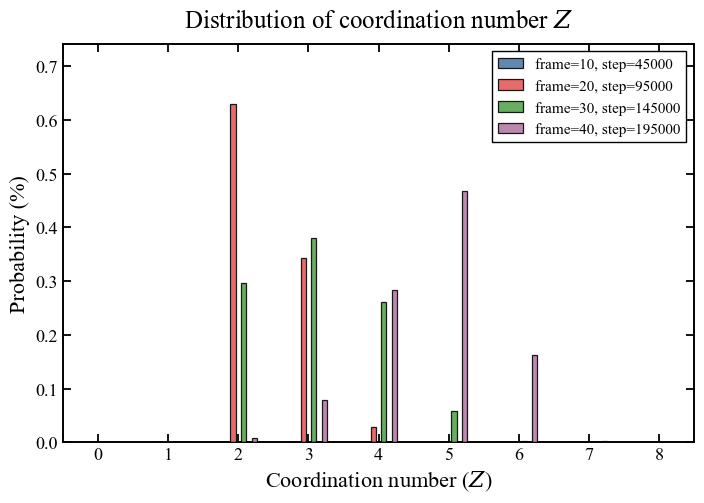

In [13]:
# 给出输入、输出路径
input_file = "compress_rate_0.001/traj_compress_rate_0.001.xyz"
output_dir = "compress_rate_0.001/z_output"
save_fig_path = "compress_rate_0.001/pictures/z_distribution_multi_frames.png"


compute_z_distribution_fn(
    INPUT_FILE=input_file,
    OUTPUT_DIR=output_dir ,
    START_FRAME=1
)


# 多帧对比
draw_z_distribution_fn(
    INPUT_DIR=output_dir,
    FRAME_LIST=[10, 20, 30, 40],
    SAVE_FIG=save_fig_path
)

# 二、研究phi=[0.67,0.73]区间

## 2.1 导入draw.py中的绘制函数

In [2]:
import sys
sys.path.append("..")   # 返回到上级目录 /Jamming 根目录


from utils.draw import draw_configurations, draw_contact_network, draw_force_chain_network

## 2.2 读取区间内轨迹数据

- 观察all_frame_tau.csv文件, 发现感兴趣区域为 step=[26,30]

In [4]:
# 使用示例
traj_file = "./compress_rate_0.001/traj_compress_rate_0.001.xyz"
frame_index = [26, 27, 28, 29, 30]


draw_configurations(traj_file, frame_index, output_dir="./compress_rate_0.001/pictures/configuration", gif_flag=True)
draw_contact_network(traj_file, frame_index, output_dir="./compress_rate_0.001/pictures/contact_network", gif_flag=True)
draw_force_chain_network(traj_file, frame_index, output_dir="./compress_rate_0.001/pictures/force_chain_network", gif_flag=True)


Generating images: 100%|██████████████████████████████████████████████| 5/5 [00:04<00:00,  1.16it/s]


所有帧的构型图已保存！
GIF动画已保存到 ./compress_rate_0.001/pictures/configuration/animation.gif


Generating images: 100%|██████████████████████████████████████████████| 5/5 [00:07<00:00,  1.55s/it]


接触网络图已保存！
GIF动画已保存到 ./compress_rate_0.001/pictures/contact_network/contact_network_animation.gif


Generating images: 100%|██████████████████████████████████████████████| 5/5 [00:07<00:00,  1.48s/it]


力链网络图已保存！
GIF动画已保存到 ./compress_rate_0.001/pictures/force_chain_network/force_chain_network_animation.gif
